In [ ]:
# ============================================
# STEP 1: IMPORT LIBRARIES AND LOAD DATASET
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from google.colab import files

# Upload the CSV file
uploaded = files.upload()

# Read the uploaded CSV file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Saving diabetes.csv to diabetes (1).csv
Dataset Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
# ============================================
# STEP 2: SELECT FEATURES FOR UNSUPERVISED ANALYSIS
# ============================================

# Select numerical features
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nShape of feature dataset:", X.shape)

display(X.head())

Selected Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Shape of feature dataset: (768, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72.0,35,169.5,33.6,0.627,50
1,1,85,66.0,29,102.5,26.6,0.351,31
2,8,183,64.0,32,169.5,23.3,0.672,32
3,1,89,66.0,23,94.0,28.1,0.167,21
4,0,137,40.0,35,168.0,43.1,2.288,33


In [ ]:
# ============================================
# STEP 3: HANDLE INVALID / MISSING VALUES
# ============================================

# Columns where zero is considered an invalid/missing value
invalid_zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Replace 0 with NaN
X[invalid_zero_columns] = X[invalid_zero_columns].replace(0, np.nan)

print("Missing values after replacing invalid zeros:")
print(X.isnull().sum())

# Fill missing values with median
for column in invalid_zero_columns:
    X[column] = X[column].fillna(X[column].median())

print("\nMissing values after median imputation:")
print(X.isnull().sum())

display(X.head())

Missing values after replacing invalid zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72.0,35,169.5,33.6,0.627,50
1,1,85,66.0,29,102.5,26.6,0.351,31
2,8,183,64.0,32,169.5,23.3,0.672,32
3,1,89,66.0,23,94.0,28.1,0.167,21
4,0,137,40.0,35,168.0,43.1,2.288,33


In [ ]:
# ============================================
# STEP 4: STANDARDIZE FEATURES
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier viewing
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

print("Standardized Dataset:")
display(X_scaled_df.head())

print("\nMean of standardized features:")
print(X_scaled_df.mean().round(2))

print("\nStandard deviation of standardized features:")
print(X_scaled_df.std().round(2))

Standardized Dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.864625,-0.032180,0.665181,0.311604,0.169483,0.468492,1.425995
1,-0.844885,-1.204727,-0.528124,-0.010112,-0.440843,-0.848549,-0.365061,-0.190672
2,1.233880,2.014265,-0.693438,0.327535,0.311604,-1.328478,0.604397,-0.105584
3,-0.844885,-1.073339,-0.528124,-0.685405,-0.536303,-0.630399,-0.920763,-1.041549
4,-1.141852,0.503310,-2.677212,0.665181,0.294758,1.551096,5.484909,-0.020496



Mean of standardized features:
Pregnancies                -0.0
Glucose                     0.0
BloodPressure              -0.0
SkinThickness               0.0
Insulin                    -0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
dtype: float64

Standard deviation of standardized features:
Pregnancies                 1.0
Glucose                     1.0
BloodPressure               1.0
SkinThickness               1.0
Insulin                     1.0
BMI                         1.0
DiabetesPedigreeFunction    1.0
Age                         1.0
dtype: float64


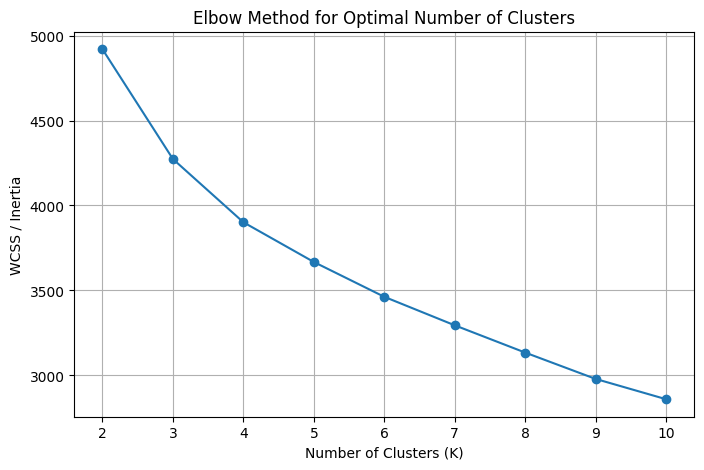

In [ ]:
# ============================================
# STEP 5 & 6: K-MEANS + ELBOW METHOD
# ============================================

wcss = []

# Test different numbers of clusters
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    wcss,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [ ]:
# ============================================
# STEP 7: SILHOUETTE SCORE
# ============================================

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

# Display scores
silhouette_results = pd.DataFrame({
    'Number of Clusters (K)': range(2, 11),
    'Silhouette Score': silhouette_scores
})

display(silhouette_results)

,Number of Clusters (K),Silhouette Score
0,2,0.205165
1,3,0.203341
2,4,0.190813
3,5,0.146521
4,6,0.171565
5,7,0.123210
6,8,0.147747
7,9,0.150434
8,10,0.149740


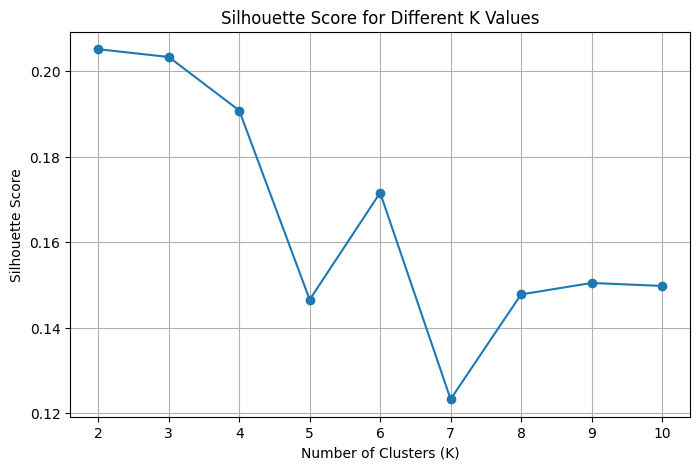

In [ ]:
# Plot Silhouette Scores

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [ ]:
# Find K with the highest Silhouette Score

best_k = range(2, 11)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("Best Number of Clusters:", best_k)
print("Highest Silhouette Score:", round(best_score, 4))

Best Number of Clusters: 2
Highest Silhouette Score: 0.2052


In [ ]:
# ============================================
# STEP 8: FINAL K-MEANS CLUSTERING
# ============================================

# Create final K-Means model
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

# Generate cluster labels
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df_clustered = df.copy()

df_clustered['Cluster'] = cluster_labels

print("Clustered Dataset:")
display(df_clustered.head())

print("\nNumber of observations in each cluster:")
print(df_clustered['Cluster'].value_counts().sort_index())

Clustered Dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72.0,35,169.5,33.6,0.627,50,1,0
1,1,85,66.0,29,102.5,26.6,0.351,31,0,1
2,8,183,64.0,32,169.5,23.3,0.672,32,1,0
3,1,89,66.0,23,94.0,28.1,0.167,21,0,1
4,0,137,40.0,35,168.0,43.1,2.288,33,1,1



Number of observations in each cluster:
Cluster
0    341
1    427
Name: count, dtype: int64


In [ ]:
# ============================================
# STEP 9: PCA DIMENSIONALITY REDUCTION
# ============================================

# Create PCA with 2 components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for PCA results
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# Add cluster information
pca_df['Cluster'] = cluster_labels

print("PCA Dataset:")
display(pca_df.head())

print("\nExplained Variance Ratio:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))

print(
    "\nTotal variance explained by 2 components:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

PCA Dataset:


,PC1,PC2,Cluster
0,1.575769,0.613465,0
1,-1.575930,-0.079637,1
2,0.734548,0.543459,0
3,-2.131111,-0.267265,1
4,0.804709,-3.506736,1



Explained Variance Ratio:
PC1: 0.2982
PC2: 0.1875

Total variance explained by 2 components: 48.57 %


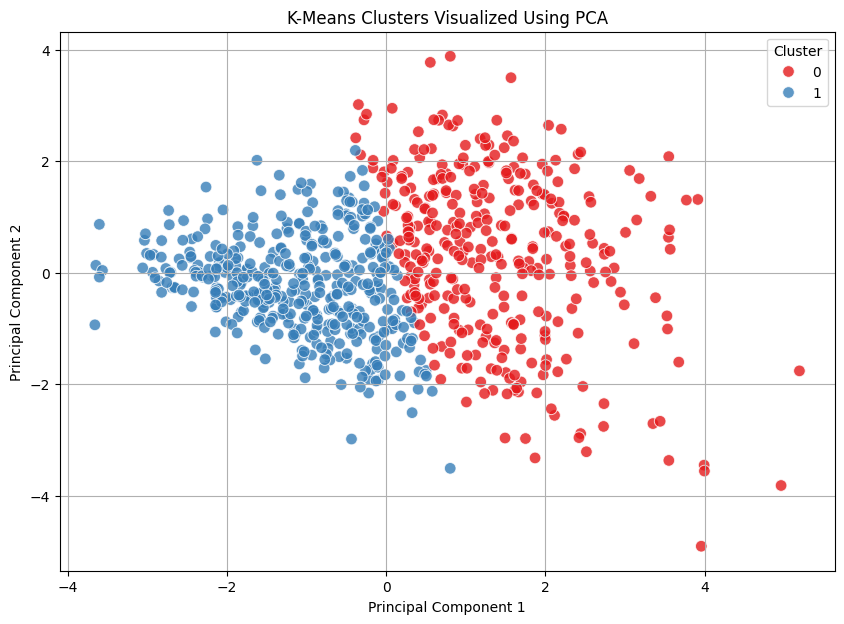

In [ ]:
# ============================================
# 2D PCA CLUSTER VISUALIZATION
# ============================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=70,
    alpha=0.8
)

plt.title('K-Means Clusters Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')

plt.grid(True)
plt.show()

In [ ]:
# ============================================
# STEP 10: CLUSTER ANALYSIS
# ============================================

# Calculate mean values for each cluster
cluster_profile = df_clustered.groupby('Cluster')[features].mean()

print("Average Feature Values for Each Cluster:")
display(cluster_profile.round(2))

Average Feature Values for Each Cluster:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,5.76,139.51,78.85,33.13,181.44,35.40,0.51,41.01
1,2.32,107.43,67.23,25.87,110.06,30.07,0.44,27.04


In [ ]:
# Standardized cluster profile for easier comparison

cluster_profile_scaled = pd.DataFrame(
    scaler.transform(cluster_profile),
    columns=features,
    index=cluster_profile.index
)

print("Standardized Cluster Profiles:")
display(cluster_profile_scaled.round(2))

Standardized Cluster Profiles:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,0.57,0.59,0.53,0.45,0.45,0.43,0.13,0.66
1,-0.45,-0.47,-0.43,-0.36,-0.36,-0.34,-0.10,-0.53


In [ ]:
# ============================================
# OPTIONAL: COMPARE CLUSTERS WITH DIABETES OUTCOME
# ============================================

outcome_by_cluster = pd.crosstab(
    df_clustered['Cluster'],
    df_clustered['Outcome'],
    normalize='index'
) * 100

print("Diabetes Outcome Distribution Within Each Cluster (%):")
display(outcome_by_cluster.round(2))

Diabetes Outcome Distribution Within Each Cluster (%):


Outcome,0,1
Cluster,,
0,39.88,60.12
1,85.25,14.75


In [ ]:
# Percentage of diabetic observations in each cluster

diabetes_rate = df_clustered.groupby('Cluster')['Outcome'].mean() * 100

print("Diabetes Rate by Cluster:")
print(diabetes_rate.round(2))

Diabetes Rate by Cluster:
Cluster
0    60.12
1    14.75
Name: Outcome, dtype: float64
